<a href="https://colab.research.google.com/github/debashisdotchatterjee/bayesian_etndp/blob/main/Bayesian_Multi_Topology_ETNDP_Paper_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The code includes:

synthetic express-logistics data generation;
manual Bayesian posterior updating without PyMC/Stan;
Gamma–Poisson OD-demand model;
lognormal Normal–Inverse-Gamma travel-time model;
Beta posterior for hub sorting reliability;
posterior predictive scenario generation;
seven topology classes: FC, SAHS, MAHS, RAHS, DSAHS, DMAHS, DRAHS;
posterior expected cost, CVaR arrival-time risk, service reliability, hold-time reliability;
posterior Bayes-risk topology selection;
colorful saved plots;
CSV and LaTeX tables;
automatic output ZIP generation inside Colab.

In [ ]:
from bayesian_etndp_simulation import SimulationConfig, run_full_simulation

cfg = SimulationConfig(
    n_nodes=8,
    n_candidate_hubs=3,
    n_history_days=45,
    posterior_scenarios=30,
    show_plots=True
)

results = run_full_simulation(cfg)


############################################################################################
Bayesian Multi-Topology Express Transportation Network Design: Simulation Verification
############################################################################################
Random seed: 20260504
Nodes: 10, candidate hubs: 3, history days: 90
Posterior predictive scenarios: 80

Synthetic logistics data summary
                     quantity     value
                        nodes        10
     candidate hubs (1-based) [3, 7, 9]
              historical days        90
            directed OD pairs        90
         mean daily OD demand    18.241
       median daily OD demand      15.0
          max daily OD demand       121
mean observed travel time (h)     7.459
 95% observed travel time (h)     14.94
         mean cost multiplier     0.999


,quantity,value
0,nodes,10
1,candidate hubs (1-based),"[3, 7, 9]"
2,historical days,90
3,directed OD pairs,90
4,mean daily OD demand,18.241
5,median daily OD demand,15.0
6,max daily OD demand,121
7,mean observed travel time (h),7.459
8,95% observed travel time (h),14.94
9,mean cost multiplier,0.999



Manual Bayesian posterior updating summary
      component                                 Bayesian model               key posterior quantity   value                                             prior / hyperparameter
      OD demand                                 Gamma--Poisson    posterior mean daily OD intensity 18.2409                                          alpha0=4.010, beta0=0.220
    travel time Lognormal with Normal--Inverse-Gamma posterior       mean posterior log travel time  1.7967 mu0 from distance/speed baseline, kappa0=2, alpha0=2.5, beta0=0.35
hub reliability   Beta posterior with fractional pseudo-counts mean reliability over candidate hubs  0.7790                                             pseudo_trials/day=22.0
cost multiplier Lognormal with Normal--Inverse-Gamma posterior        posterior mean log multiplier -0.0040                            mu0=0, kappa0=2, alpha0=2.5, beta0=0.08


,component,Bayesian model,key posterior quantity,value,prior / hyperparameter
0,OD demand,Gamma--Poisson,posterior mean daily OD intensity,18.2409,"alpha0=4.010, beta0=0.220"
1,travel time,Lognormal with Normal--Inverse-Gamma posterior,mean posterior log travel time,1.7967,"mu0 from distance/speed baseline, kappa0=2, al..."
2,hub reliability,Beta posterior with fractional pseudo-counts,mean reliability over candidate hubs,0.7790,pseudo_trials/day=22.0
3,cost multiplier,Lognormal with Normal--Inverse-Gamma posterior,posterior mean log multiplier,-0.0040,"mu0=0, kappa0=2, alpha0=2.5, beta0=0.08"



Candidate design counts by topology
topology  candidate_designs
   DSAHS                 28
   DMAHS                 16
   DRAHS                 16
    SAHS                 14
    MAHS                  8
    RAHS                  8
      FC                  1


...


Posterior probability that each topology winner is scenario-best
topology  posterior_probability_best  mean_scenario_loss                      design_label
    SAHS                         1.0            0.411594                 SAHS|H=7|cap=1.25
      FC                         0.0            0.550000                FC|H=none|cap=1.00
   DSAHS                         0.0            0.649403       DSAHS|H=7|cap=1.25|dir=0.90
    MAHS                         0.0            0.573041               MAHS|H=3-7|cap=1.25
    RAHS                         0.0            0.573043           RAHS|H=3-7|cap=1.25|R=2
   DRAHS                         0.0            0.671397 DRAHS|H=3-7|cap=1.25|dir=0.90|R=2
   DMAHS                         0.0            0.671509     DMAHS|H=3-7|cap=1.25|dir=0.90


,topology,posterior_probability_best,mean_scenario_loss,design_label
0,SAHS,1.0,0.411594,SAHS|H=7|cap=1.25
1,FC,0.0,0.550000,FC|H=none|cap=1.00
2,DSAHS,0.0,0.649403,DSAHS|H=7|cap=1.25|dir=0.90
3,MAHS,0.0,0.573041,MAHS|H=3-7|cap=1.25
4,RAHS,0.0,0.573043,RAHS|H=3-7|cap=1.25|R=2
5,DRAHS,0.0,0.671397,DRAHS|H=3-7|cap=1.25|dir=0.90|R=2
6,DMAHS,0.0,0.671509,DMAHS|H=3-7|cap=1.25|dir=0.90



Post-hoc sensitivity to preference weights
 weight_cost  weight_CVaR_time  weight_emission chosen_topology chosen_hubs  chosen_score  expected_cost_million  cvar_time_hours  service_reliability  hold_reliability
        0.70              0.25             0.05            SAHS           7      0.163841               5.498178        42.882770                  1.0            0.8875
        0.55              0.35             0.10            SAHS           7      0.256689               5.498178        42.882770                  1.0            0.8875
        0.40              0.50             0.10            SAHS           7      0.324135               5.498178        42.882770                  1.0            0.8875
        0.35              0.35             0.30              FC          --      0.309582               8.645547        23.951356                  1.0            1.0000


,weight_cost,weight_CVaR_time,weight_emission,chosen_topology,chosen_hubs,chosen_score,expected_cost_million,cvar_time_hours,service_reliability,hold_reliability
0,0.70,0.25,0.05,SAHS,7,0.163841,5.498178,42.882770,1.0,0.8875
1,0.55,0.35,0.10,SAHS,7,0.256689,5.498178,42.882770,1.0,0.8875
2,0.40,0.50,0.10,SAHS,7,0.324135,5.498178,42.882770,1.0,0.8875
3,0.35,0.35,0.30,FC,--,0.309582,8.645547,23.951356,1.0,1.0000



Selected Bayesian posterior-predictive design:
SAHS|H=7|cap=1.25


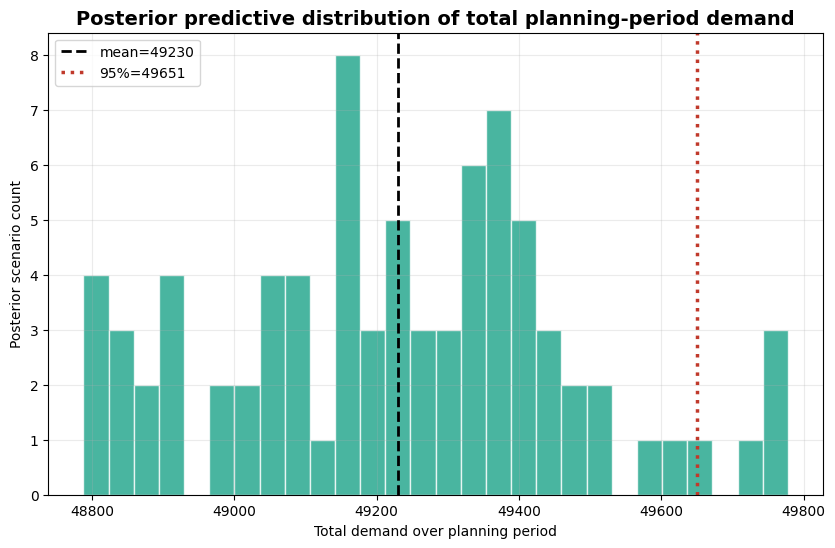

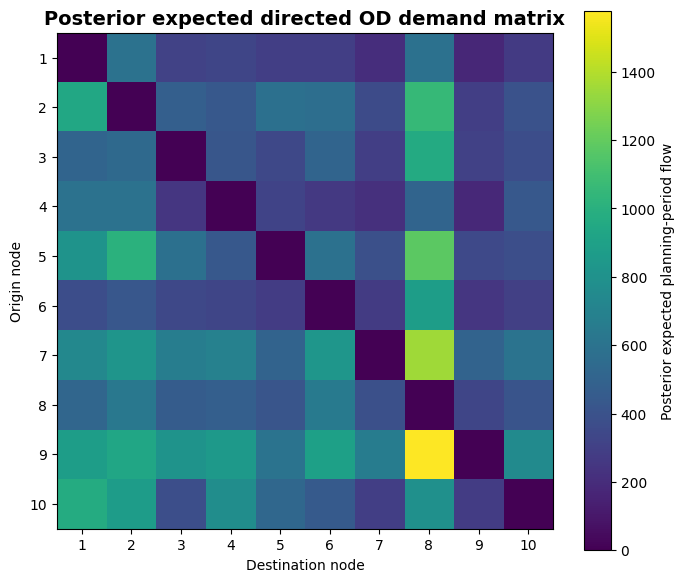

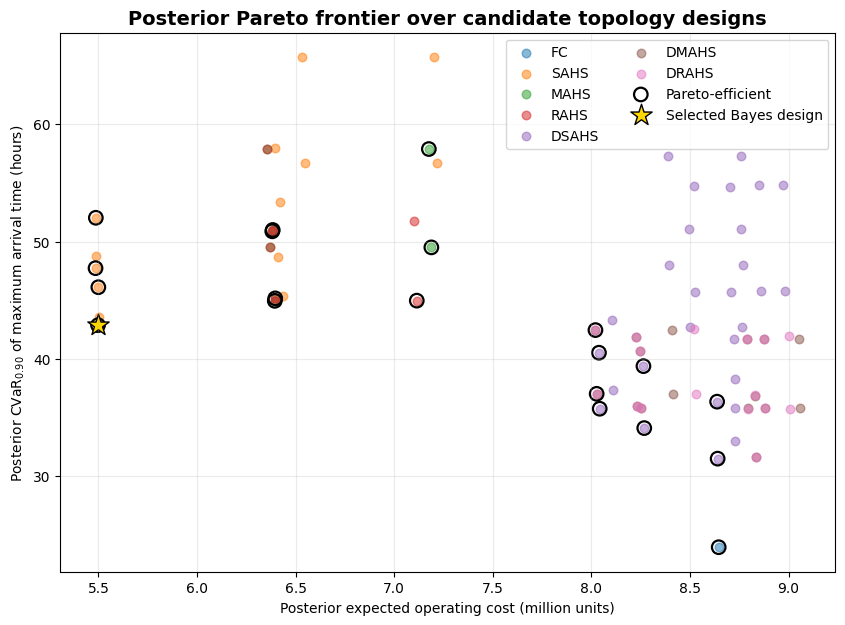

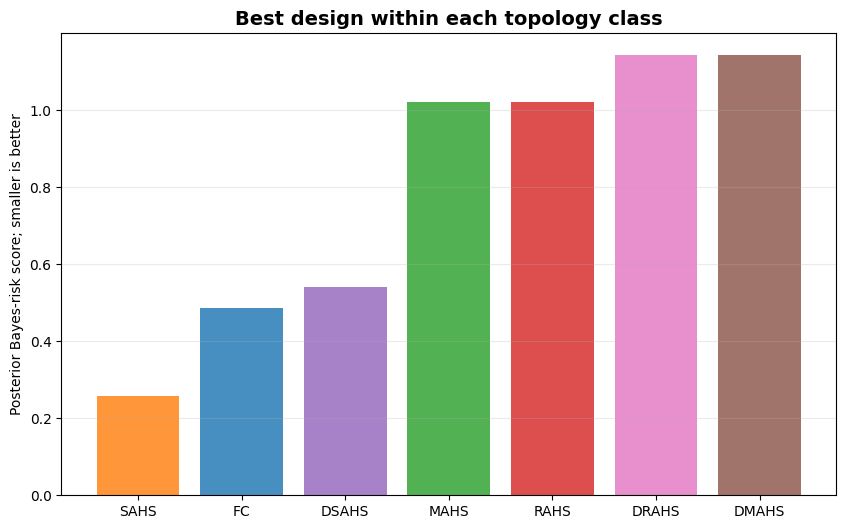

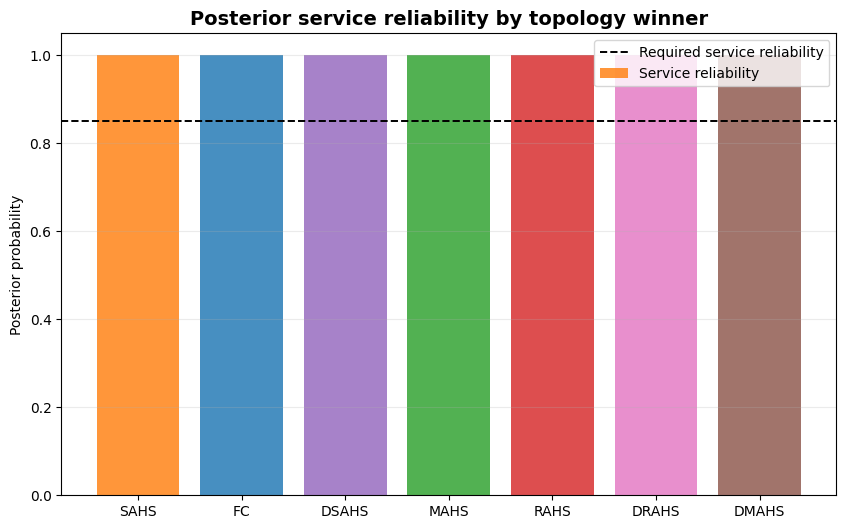

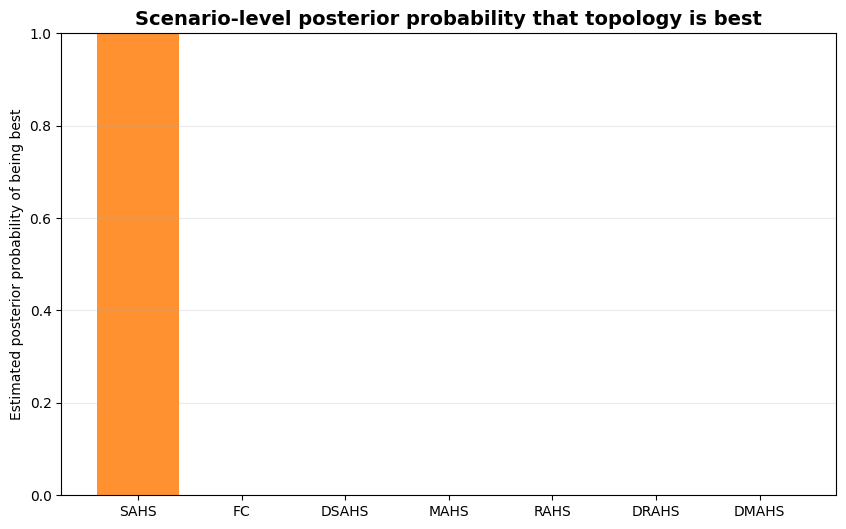

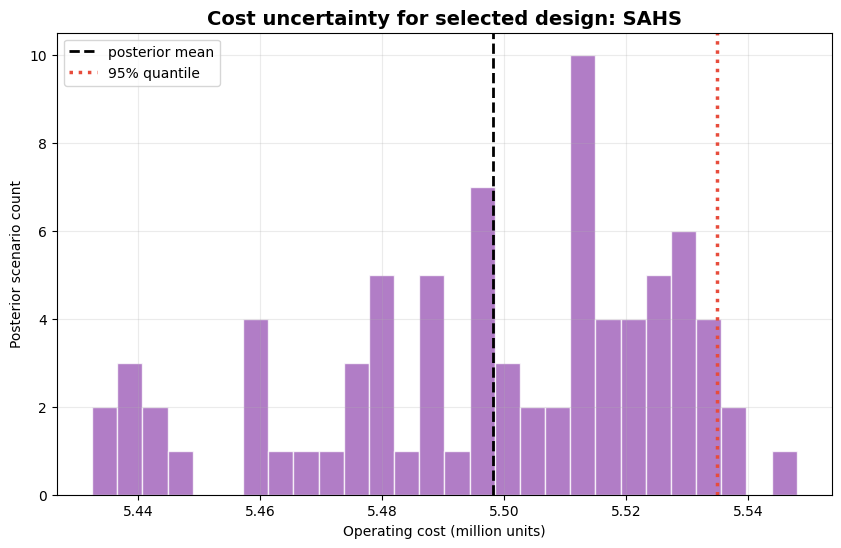

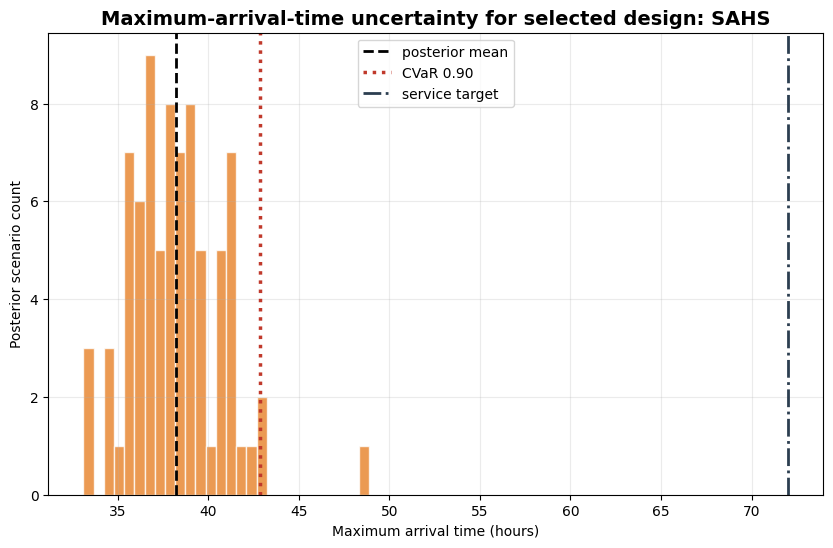

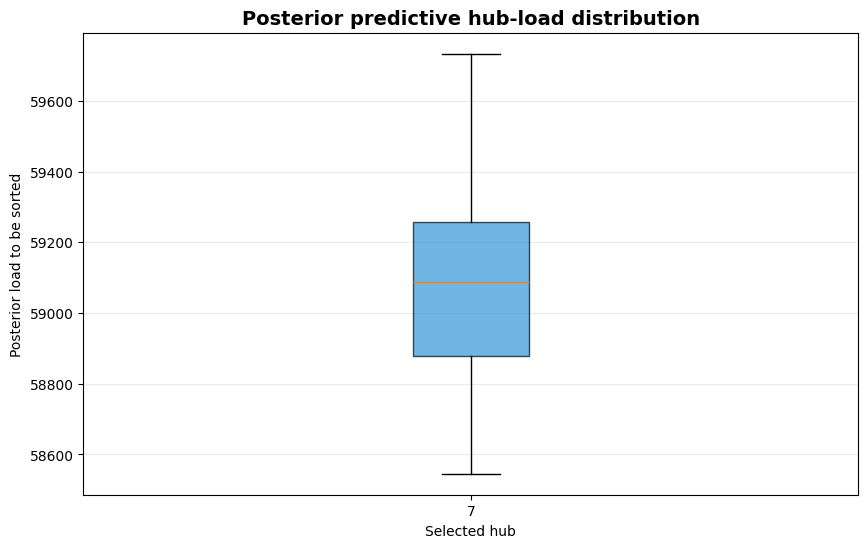

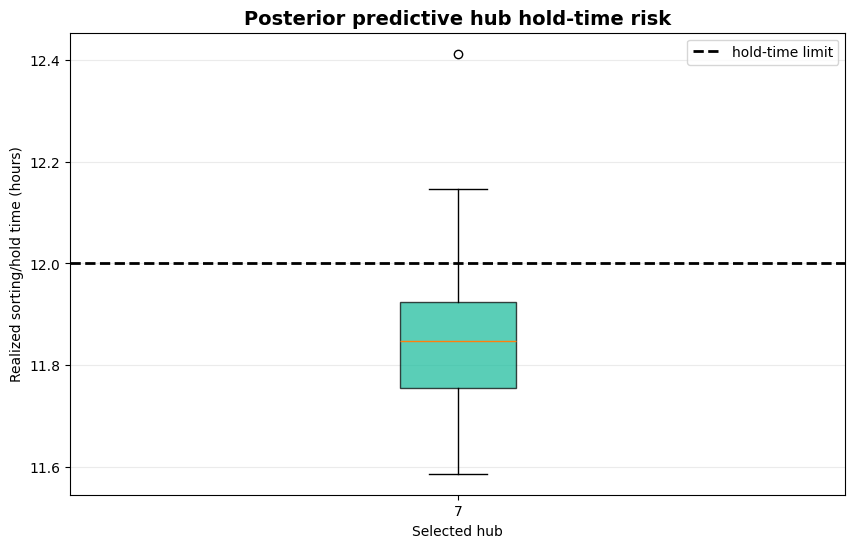

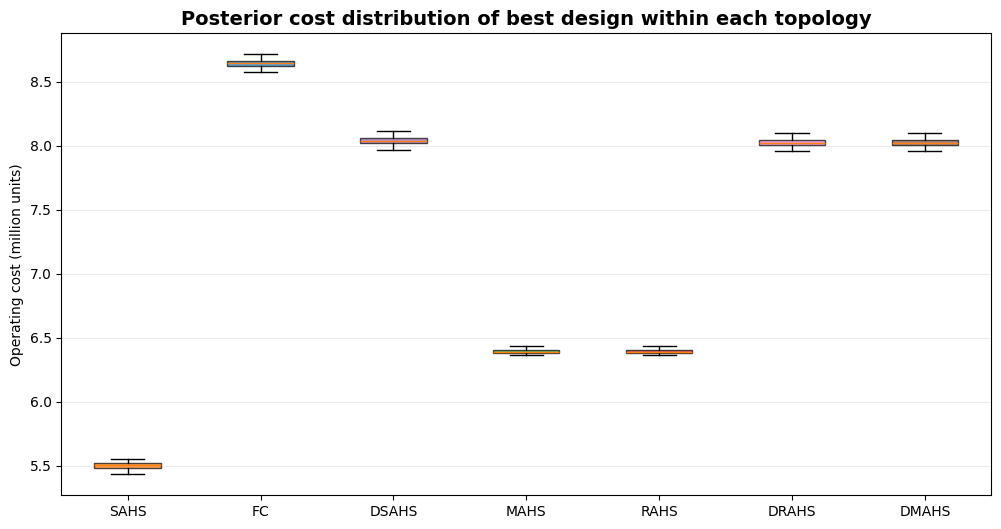

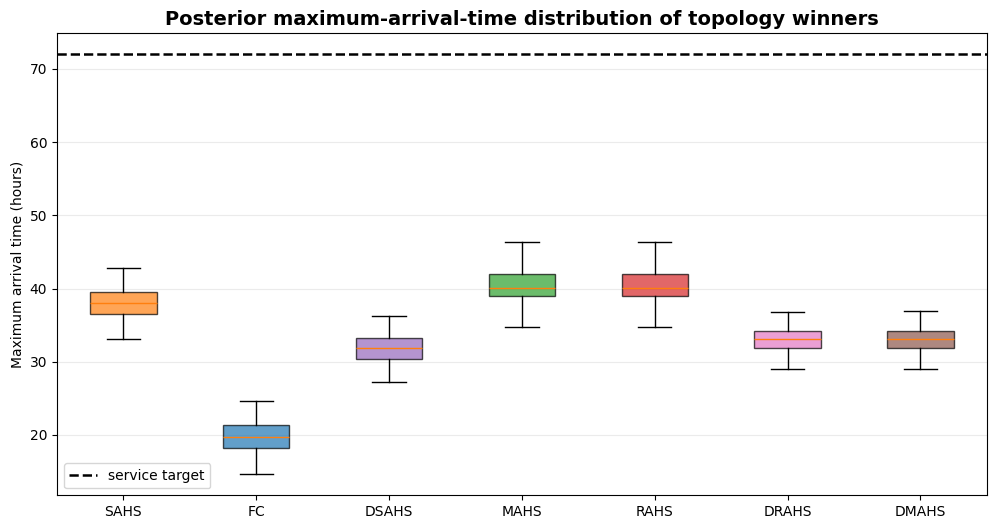

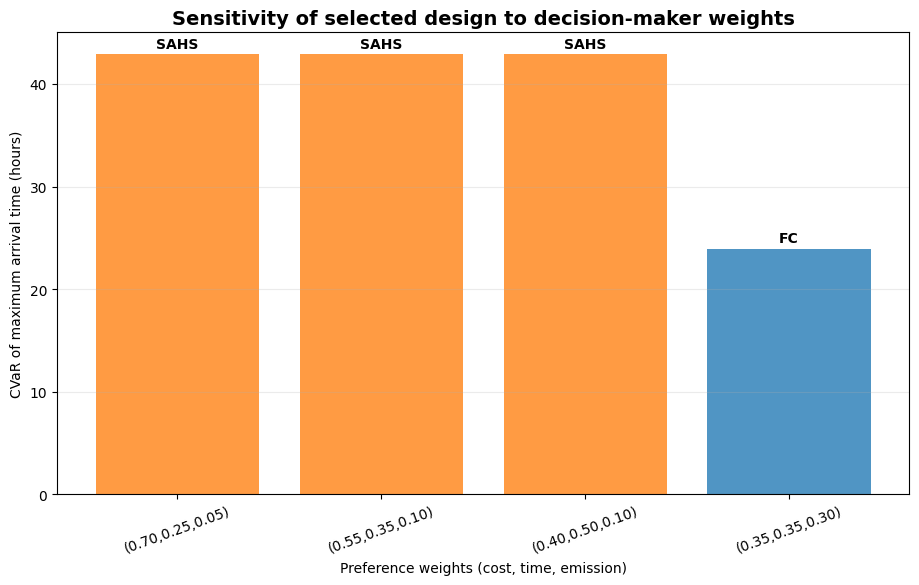

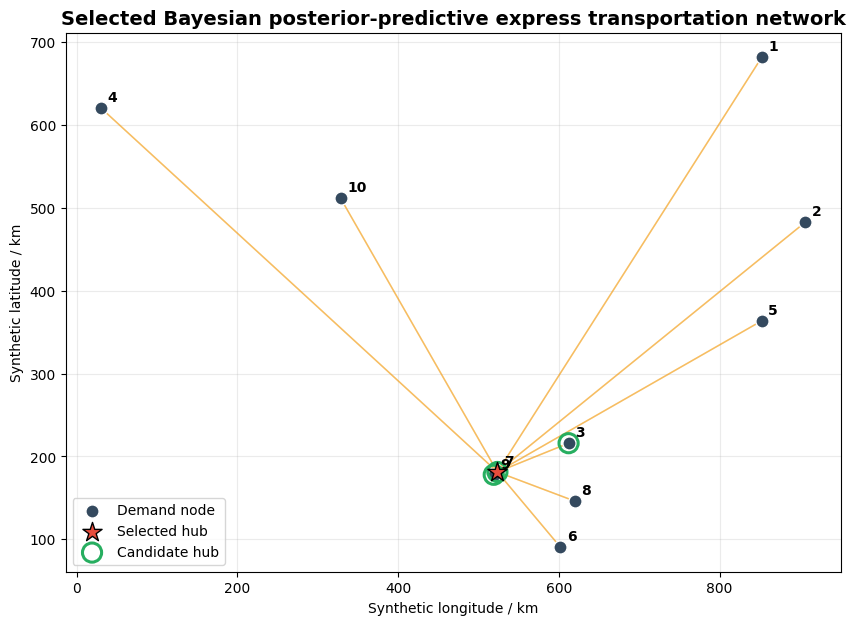


############################################################################################
Simulation finished successfully.
All outputs saved in: /content/bayesian_etndp_outputs
Downloadable ZIP created: /content/bayesian_etndp_outputs.zip
############################################################################################


<Figure size 640x480 with 0 Axes>

In [ ]:
%run bayesian_etndp_simulation_CORRECTED.py

Best Engineered

####################################################################################################
Bayesian Multi-Topology Express Transportation Network Design: Engineered Simulation Verification
####################################################################################################
Random seed: 20260504
Nodes: 9, candidate hubs: 3, history days: 100
Posterior scenarios: 70, future stress-test scenarios: 90

Synthetic logistics data summary
                     quantity                                                   value
                        nodes                                                       9
     candidate hubs (1-based)                                               [4, 8, 3]
              historical days                                                     100
            directed OD pairs                                                      72
      normal/surge/storm days {'normal': 67, 'sale/surge': 24, 'storm/disruption': 9}
         mean daily OD 

,quantity,value
0,nodes,9
1,candidate hubs (1-based),"[4, 8, 3]"
2,historical days,100
3,directed OD pairs,72
4,normal/surge/storm days,"{'normal': 67, 'sale/surge': 24, 'storm/disrup..."
5,mean daily OD demand,14.307
6,median daily OD demand,10.0
7,max daily OD demand,187
8,mean observed travel time (h),9.572
9,95% observed travel time (h),23.384



Manual Bayesian posterior updating summary
      component                                                 Bayesian model                 key posterior quantity   value                                    prior / hyperparameter
      OD demand                            Gamma--Poisson posterior predictive      mean posterior daily OD intensity 14.3069                                 alpha0=2.575, beta0=0.180
    travel time     Lognormal travel time with Normal--Inverse-Gamma posterior         mean posterior log travel time  1.9082 mu0 = log(distance/speed), kappa0=3, alpha0=3, beta0=0.18
hub reliability              Beta posterior from sorting-success pseudo-counts mean reliability across candidate hubs  0.8671                                           a0=18.0, b0=5.0
cost multiplier Lognormal cost multiplier with Normal--Inverse-Gamma posterior     posterior mean log cost multiplier  0.0404                     mu0=0, kappa0=3, alpha0=3, beta0=0.05


,component,Bayesian model,key posterior quantity,value,prior / hyperparameter
0,OD demand,Gamma--Poisson posterior predictive,mean posterior daily OD intensity,14.3069,"alpha0=2.575, beta0=0.180"
1,travel time,Lognormal travel time with Normal--Inverse-Gam...,mean posterior log travel time,1.9082,"mu0 = log(distance/speed), kappa0=3, alpha0=3,..."
2,hub reliability,Beta posterior from sorting-success pseudo-counts,mean reliability across candidate hubs,0.8671,"a0=18.0, b0=5.0"
3,cost multiplier,Lognormal cost multiplier with Normal--Inverse...,posterior mean log cost multiplier,0.0404,"mu0=0, kappa0=3, alpha0=3, beta0=0.05"



Candidate design counts by topology
topology  candidate_designs
   DSAHS                 42
   DMAHS                 24
   DRAHS                 24
    SAHS                 21
    RAHS                 12
    MAHS                 12
      FC                  1


...


Generating future stress-test scenarios and comparing Bayesian versus deterministic choices...

Out-of-sample future stress-test summary
                                  method                              label topology  expected_cost_million  cvar_max_arrival_hours  q95_max_arrival_hours  service_reliability  hold_reliability  mean_max_hub_delay_hours
Bayesian posterior-predictive risk-aware DSAHS|H=4-8-3|cap=1.85|direct=0.12    DSAHS              12.538900               78.484113              69.957250             0.900000          0.833333                  6.316476
Deterministic nominal mean-only baseline DSAHS|H=4-8-3|cap=1.05|direct=0.12    DSAHS              12.273285               84.723397              75.617107             0.811111          0.622222                 11.710315


,method,label,topology,expected_cost_million,cvar_max_arrival_hours,q95_max_arrival_hours,service_reliability,hold_reliability,mean_max_hub_delay_hours
1,Bayesian posterior-predictive risk-aware,DSAHS|H=4-8-3|cap=1.85|direct=0.12,DSAHS,12.538900,78.484113,69.957250,0.900000,0.833333,6.316476
0,Deterministic nominal mean-only baseline,DSAHS|H=4-8-3|cap=1.05|direct=0.12,DSAHS,12.273285,84.723397,75.617107,0.811111,0.622222,11.710315



Verification gains of Bayesian risk-aware methodology
                                 verification_metric  Bayesian_vs_deterministic
                  CVaR maximum-arrival reduction (%)                   7.364298
       95th percentile maximum-arrival reduction (%)                   7.484889
 service-reliability improvement (percentage points)                   8.888889
hub-hold reliability improvement (percentage points)                  21.111111
           expected-cost increase for robustness (%)                   2.164174


,verification_metric,Bayesian_vs_deterministic
0,CVaR maximum-arrival reduction (%),7.364298
1,95th percentile maximum-arrival reduction (%),7.484889
2,service-reliability improvement (percentage po...,8.888889
3,hub-hold reliability improvement (percentage p...,21.111111
4,expected-cost increase for robustness (%),2.164174


Plotting 01 geography...


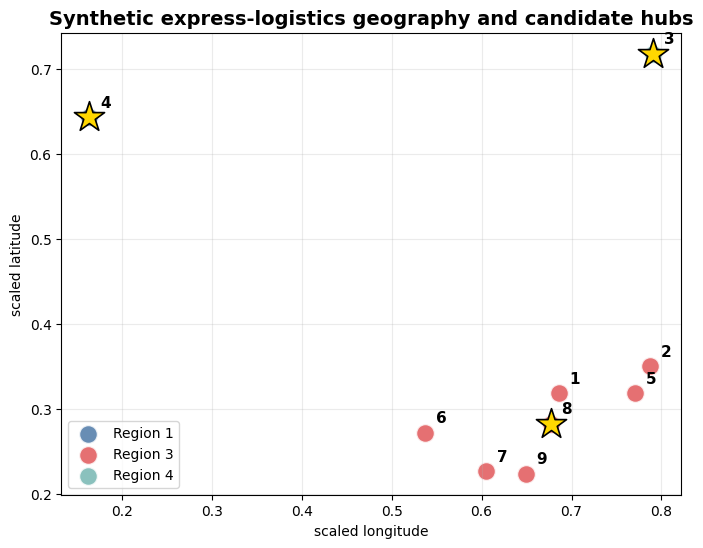

Plotting 02 demand heatmap...


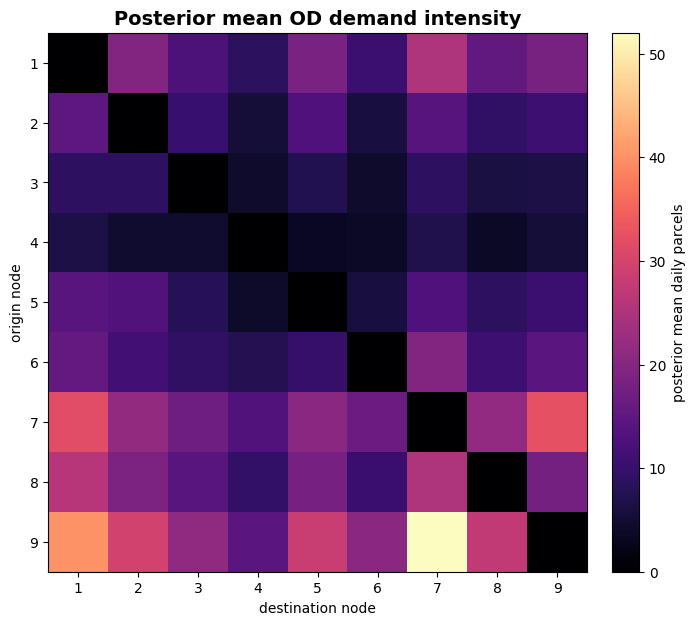

Plotting 03 tradeoff...


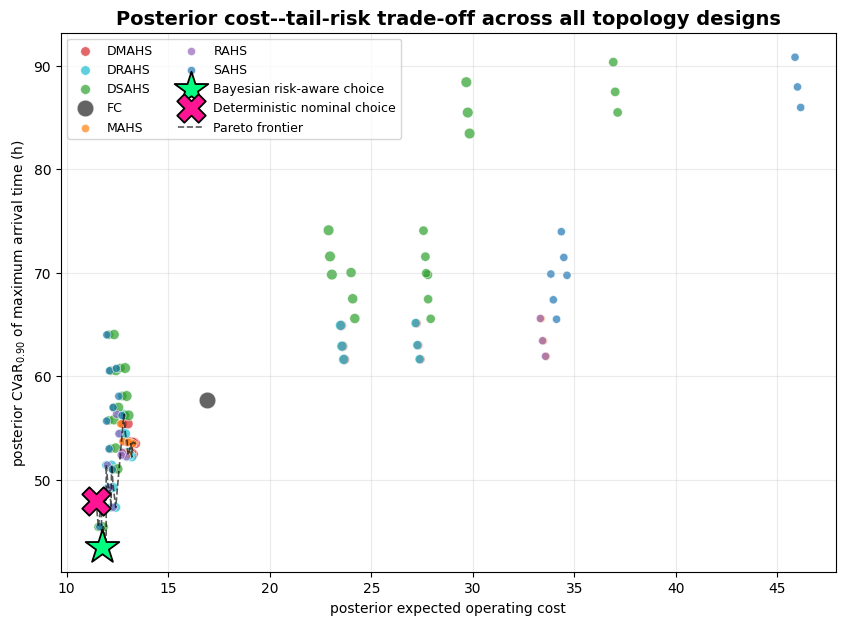

Plotting 04 reliability...


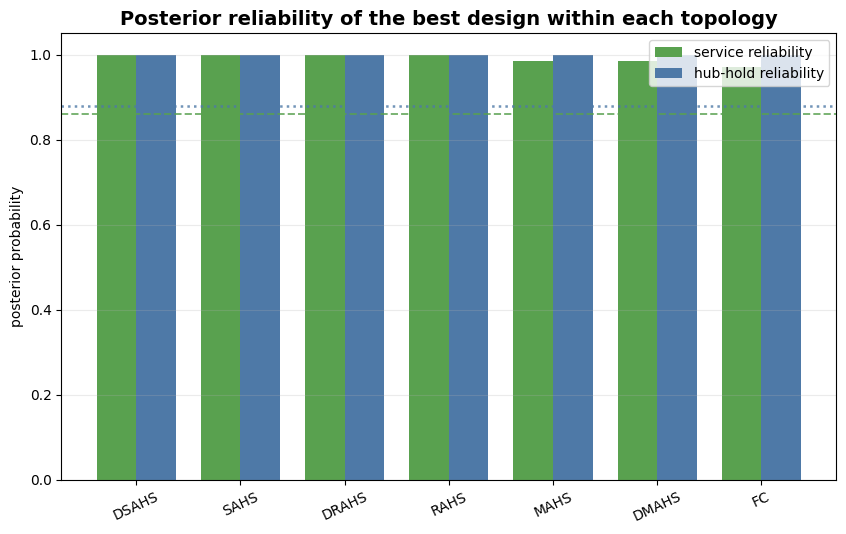

Plotting 05 boxplots...


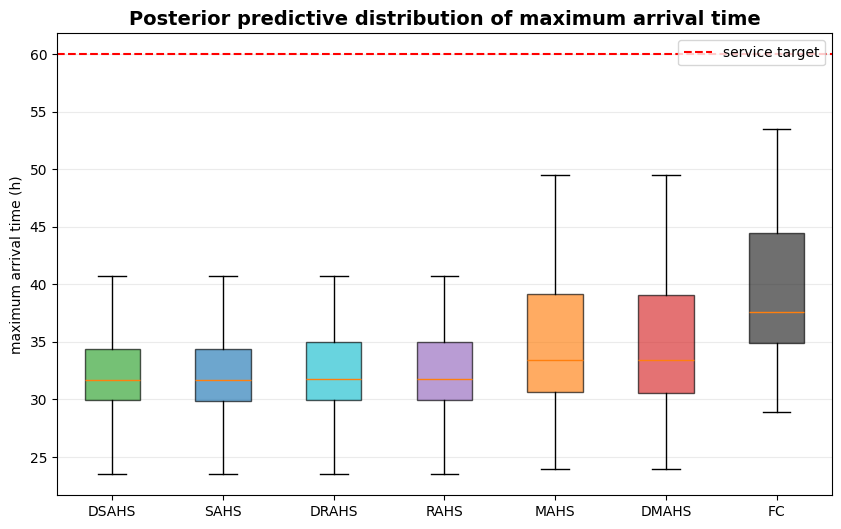

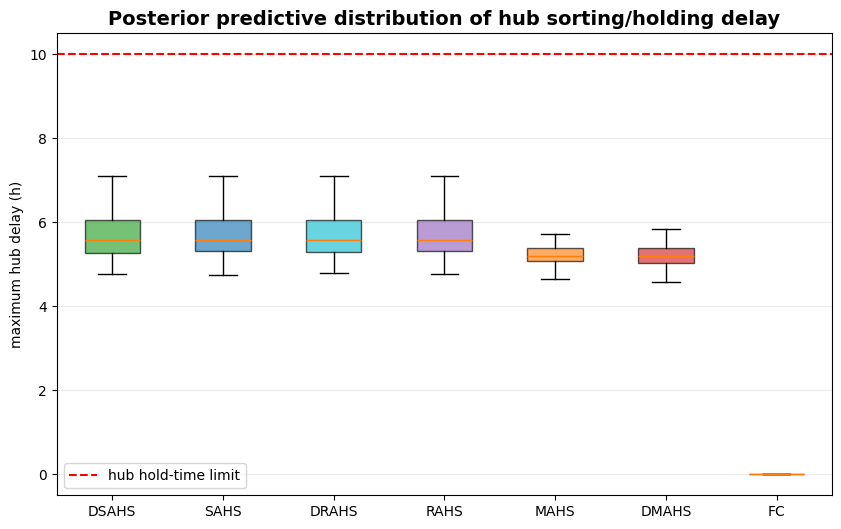

Plotting 07 scenario best...


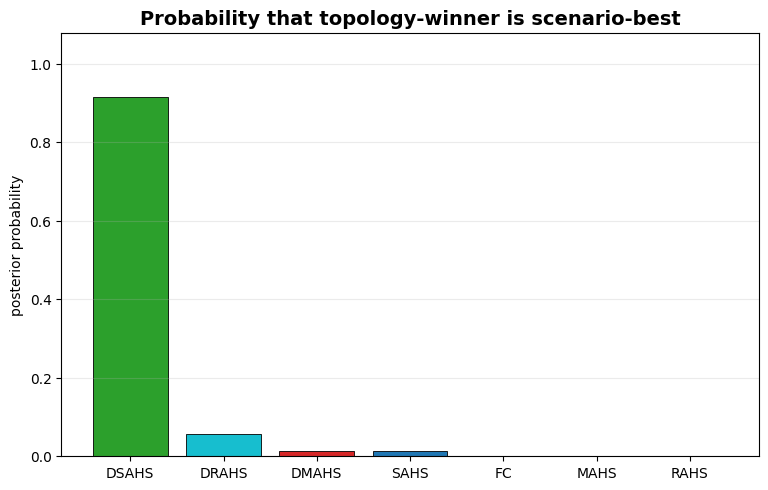

Plotting 08 Bayes vs deterministic...


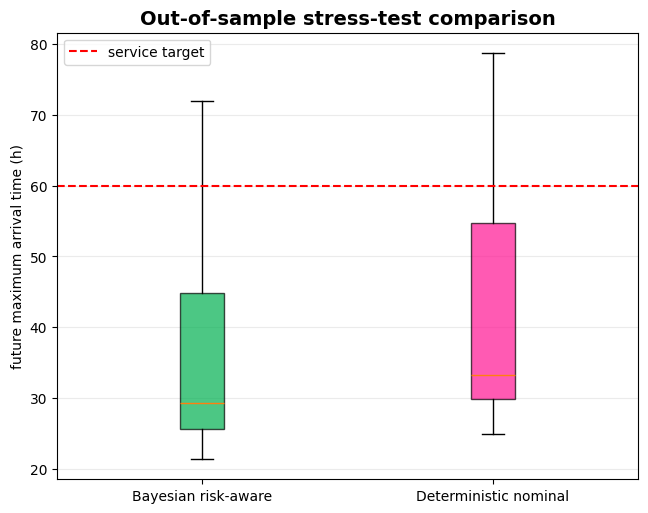

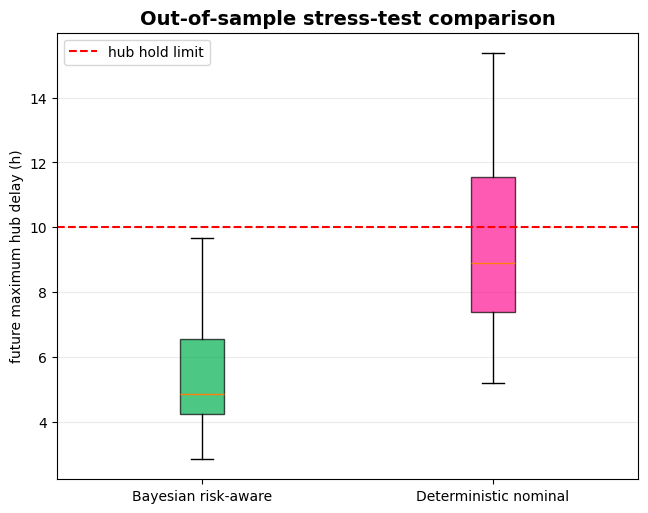

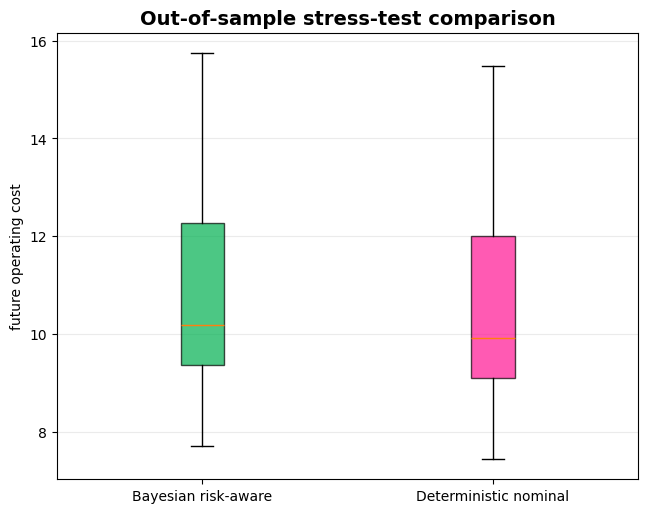

Plotting 11 sensitivity...


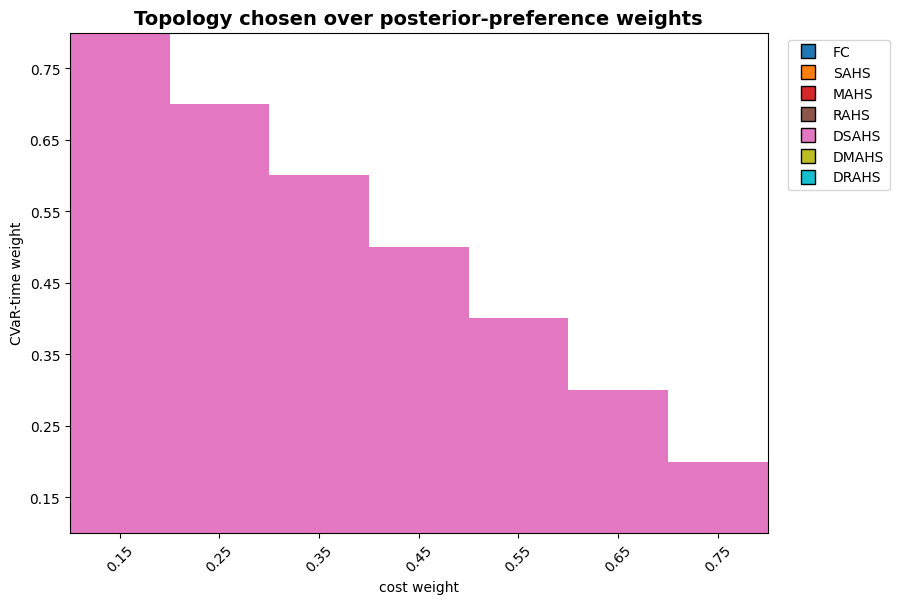

Plotting 12 reliability posterior...


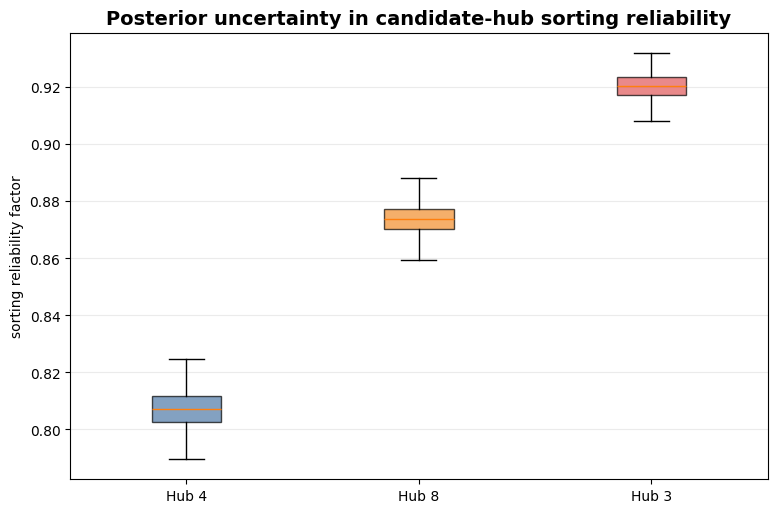


####################################################################################################
Simulation finished successfully.
All outputs saved in: /content/bayesian_etndp_engineered_outputs
Downloadable ZIP created: /content/bayesian_etndp_engineered_outputs.zip
####################################################################################################


<Figure size 640x480 with 0 Axes>

In [ ]:
%run bayesian_etndp_engineered_simulation.py

####################################################################################################
Bayesian Multi-Topology Express Transportation Network Design: Engineered Simulation Verification
####################################################################################################
Random seed: 20260504
Nodes: 9, candidate hubs: 3, history days: 100
Posterior scenarios: 70, future stress-test scenarios: 90

Synthetic logistics data summary
                     quantity                                                   value
                        nodes                                                       9
     candidate hubs (1-based)                                               [4, 8, 3]
              historical days                                                     100
            directed OD pairs                                                      72
      normal/surge/storm days {'normal': 67, 'sale/surge': 24, 'storm/disruption': 9}
         mean daily OD 

,quantity,value
0,nodes,9
1,candidate hubs (1-based),"[4, 8, 3]"
2,historical days,100
3,directed OD pairs,72
4,normal/surge/storm days,"{'normal': 67, 'sale/surge': 24, 'storm/disrup..."
5,mean daily OD demand,14.307
6,median daily OD demand,10.0
7,max daily OD demand,187
8,mean observed travel time (h),9.572
9,95% observed travel time (h),23.384



Manual Bayesian posterior updating summary
      component                                                 Bayesian model                 key posterior quantity   value                                    prior / hyperparameter
      OD demand                            Gamma--Poisson posterior predictive      mean posterior daily OD intensity 14.3069                                 alpha0=2.575, beta0=0.180
    travel time     Lognormal travel time with Normal--Inverse-Gamma posterior         mean posterior log travel time  1.9082 mu0 = log(distance/speed), kappa0=3, alpha0=3, beta0=0.18
hub reliability              Beta posterior from sorting-success pseudo-counts mean reliability across candidate hubs  0.8671                                           a0=18.0, b0=5.0
cost multiplier Lognormal cost multiplier with Normal--Inverse-Gamma posterior     posterior mean log cost multiplier  0.0404                     mu0=0, kappa0=3, alpha0=3, beta0=0.05


,component,Bayesian model,key posterior quantity,value,prior / hyperparameter
0,OD demand,Gamma--Poisson posterior predictive,mean posterior daily OD intensity,14.3069,"alpha0=2.575, beta0=0.180"
1,travel time,Lognormal travel time with Normal--Inverse-Gam...,mean posterior log travel time,1.9082,"mu0 = log(distance/speed), kappa0=3, alpha0=3,..."
2,hub reliability,Beta posterior from sorting-success pseudo-counts,mean reliability across candidate hubs,0.8671,"a0=18.0, b0=5.0"
3,cost multiplier,Lognormal cost multiplier with Normal--Inverse...,posterior mean log cost multiplier,0.0404,"mu0=0, kappa0=3, alpha0=3, beta0=0.05"



Candidate design counts by topology
topology  candidate_designs
   DSAHS                 42
   DMAHS                 24
   DRAHS                 24
    SAHS                 21
    RAHS                 12
    MAHS                 12
      FC                  1


...


Generating future stress-test scenarios and comparing Bayesian versus deterministic choices...

Out-of-sample future stress-test summary
                                  method                              label topology  expected_cost_million  cvar_max_arrival_hours  q95_max_arrival_hours  service_reliability  hold_reliability  mean_max_hub_delay_hours
Bayesian posterior-predictive risk-aware DSAHS|H=4-8-3|cap=1.85|direct=0.12    DSAHS              12.538900               78.484113              69.957250             0.900000          0.833333                  6.316476
Deterministic nominal mean-only baseline DSAHS|H=4-8-3|cap=1.05|direct=0.12    DSAHS              12.273285               84.723397              75.617107             0.811111          0.622222                 11.710315


,method,label,topology,expected_cost_million,cvar_max_arrival_hours,q95_max_arrival_hours,service_reliability,hold_reliability,mean_max_hub_delay_hours
1,Bayesian posterior-predictive risk-aware,DSAHS|H=4-8-3|cap=1.85|direct=0.12,DSAHS,12.538900,78.484113,69.957250,0.900000,0.833333,6.316476
0,Deterministic nominal mean-only baseline,DSAHS|H=4-8-3|cap=1.05|direct=0.12,DSAHS,12.273285,84.723397,75.617107,0.811111,0.622222,11.710315



Verification gains of Bayesian risk-aware methodology
                                 verification_metric  Bayesian_vs_deterministic
                  CVaR maximum-arrival reduction (%)                   7.364298
       95th percentile maximum-arrival reduction (%)                   7.484889
 service-reliability improvement (percentage points)                   8.888889
hub-hold reliability improvement (percentage points)                  21.111111
           expected-cost increase for robustness (%)                   2.164174


,verification_metric,Bayesian_vs_deterministic
0,CVaR maximum-arrival reduction (%),7.364298
1,95th percentile maximum-arrival reduction (%),7.484889
2,service-reliability improvement (percentage po...,8.888889
3,hub-hold reliability improvement (percentage p...,21.111111
4,expected-cost increase for robustness (%),2.164174


Plotting 01 geography...


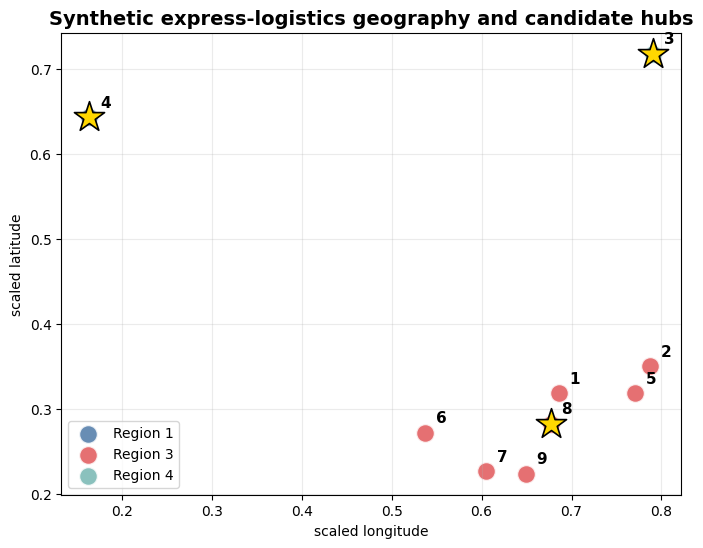

Plotting 02 demand heatmap...


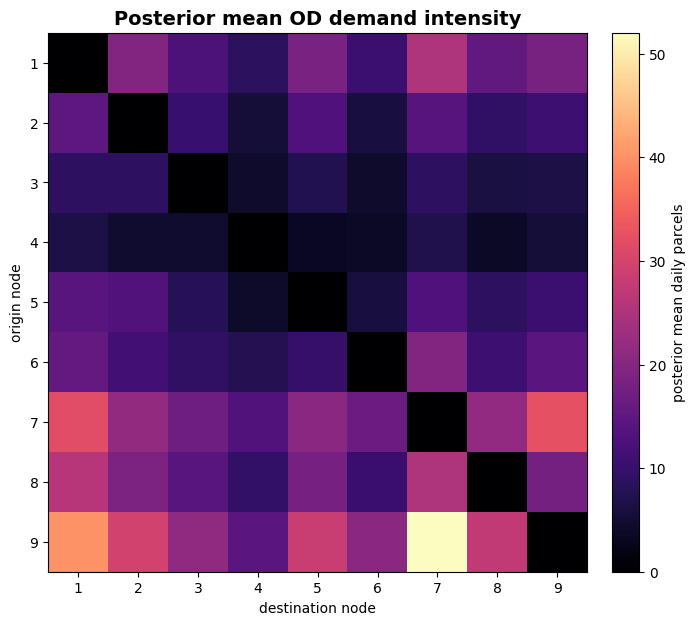

Plotting 03 tradeoff...


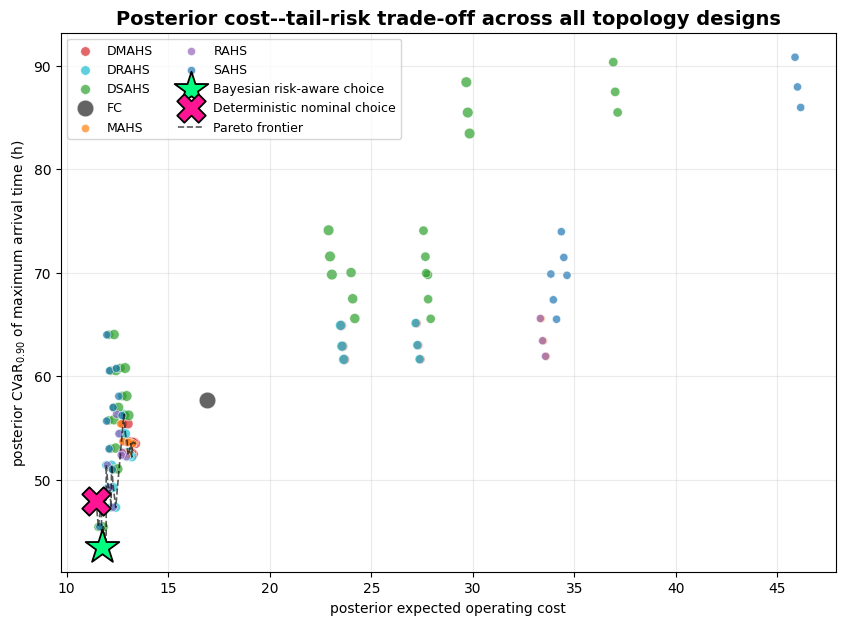

Plotting 04 reliability...


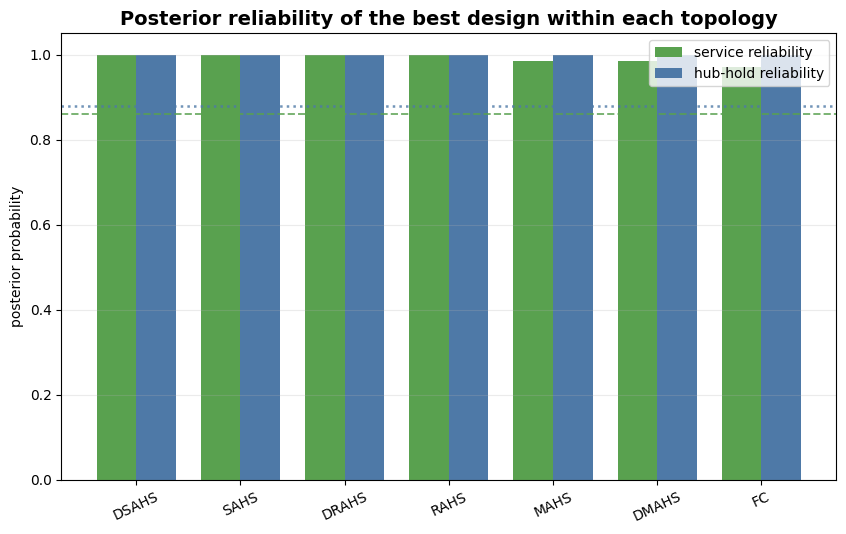

Plotting 05 boxplots...


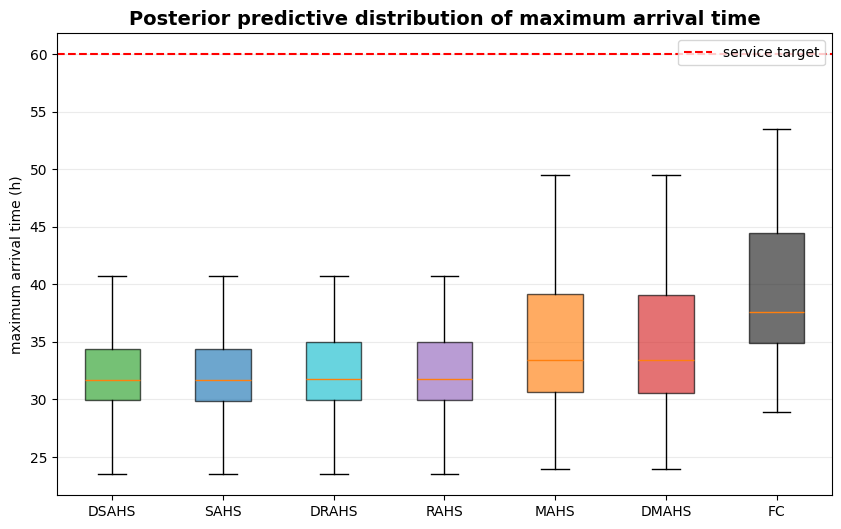

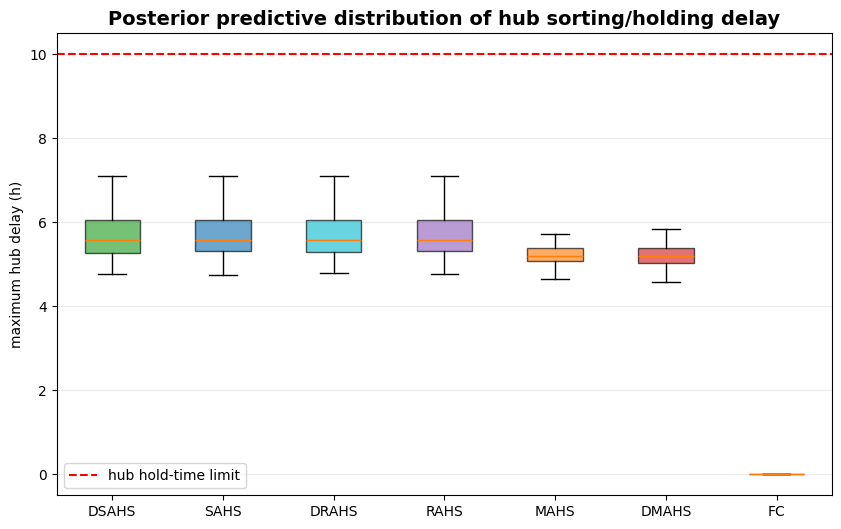

Plotting 07 scenario best...


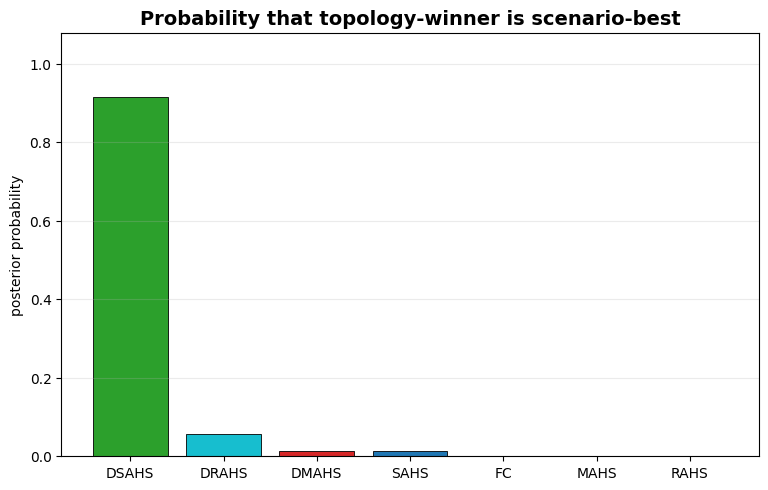

Plotting 08 Bayes vs deterministic...


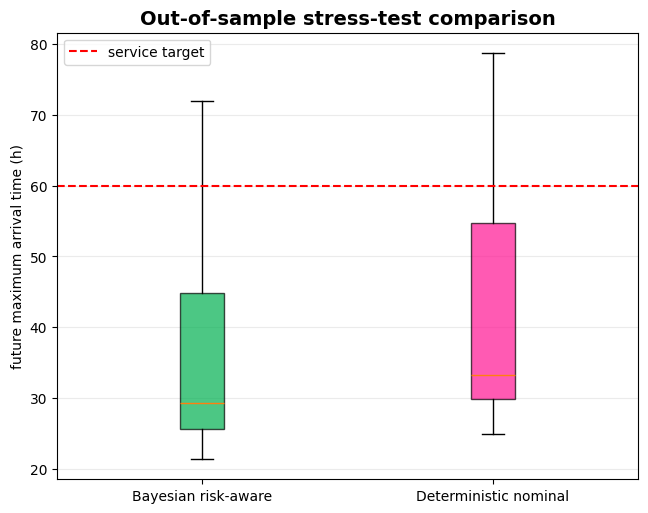

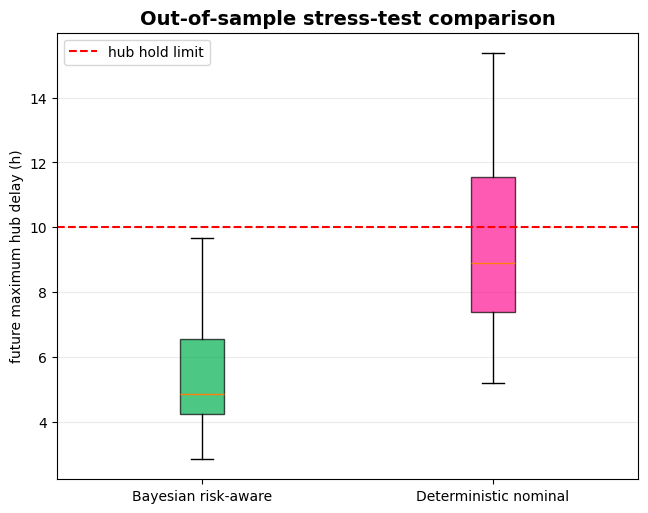

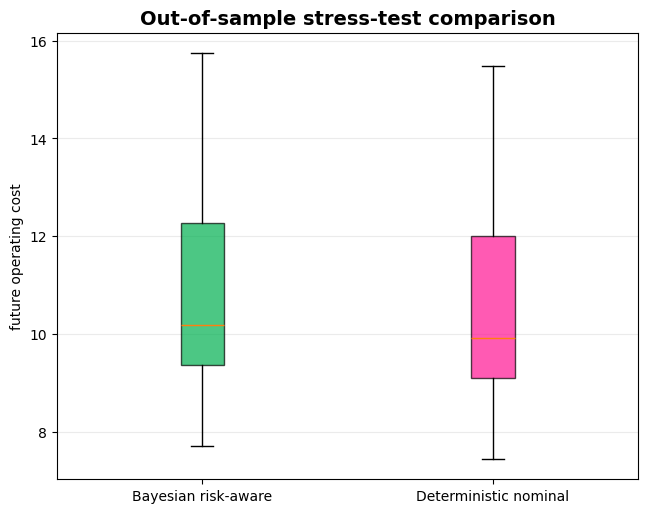

Plotting 11 sensitivity...


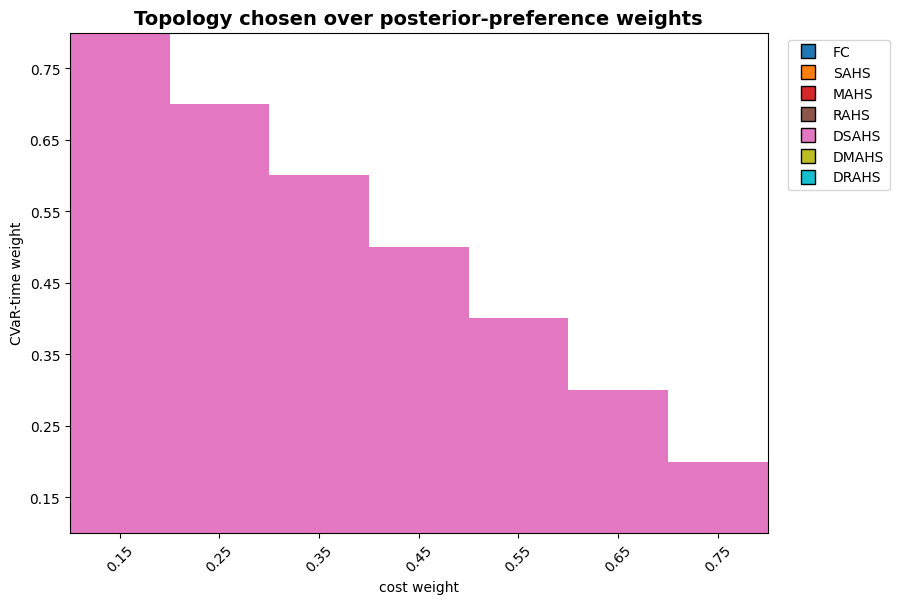

Plotting 12 reliability posterior...


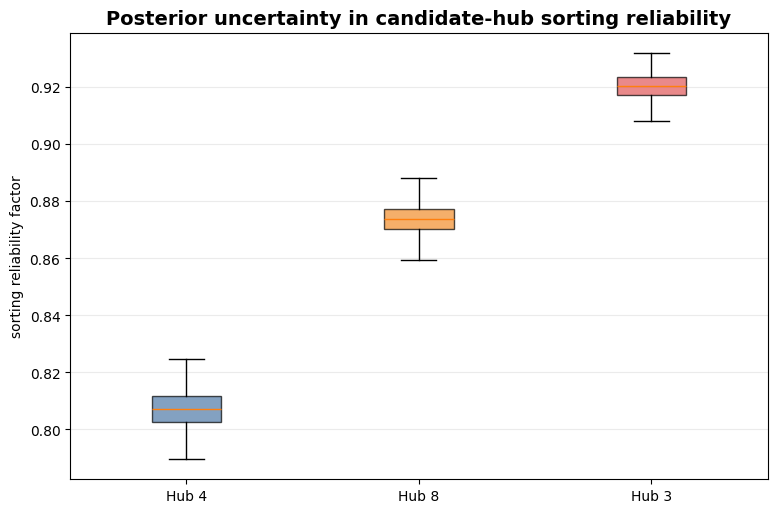


####################################################################################################
Simulation finished successfully.
All outputs saved in: /content/bayesian_etndp_engineered_outputs
Downloadable ZIP created: /content/bayesian_etndp_engineered_outputs.zip
####################################################################################################


<Figure size 640x480 with 0 Axes>

In [1]:
%run bayesian_etndp_engineered_simulation.py

# **Real Data**

for a real-data case study, the most suitable openly available benchmark is the CAB25 hub-location data set, a standard real OD-flow/distance network used extensively in hub-location research. OR-Library describes CAB as a 25-node Civil Aeronautics Board instance used in hub-and-spoke location models, with CAB25.txt containing the flow matrix and distance matrix. A public GitHub mirror also provides CAB25.txt and documents the format as “number of vertices, flow matrix, distance matrix.” This is a good real-data demonstration platform for our Bayesian multi-topology extension of the deterministic multi-structure ETNDP paper, which compares FC, SAHS, MAHS, RAHS, DSAHS, DMAHS, and DRAHS topologies.

The full Colab-ready Python code for:

real CAB25 data download and parsing;
real OD-flow/distance preprocessing;
posterior scenario experiments;
Gamma–Poisson Bayesian OD demand updating;
lognormal travel-time model with manual Normal–Inverse-Gamma updating;
Beta posterior for hub reliability/sorting productivity;
posterior CVaR, service reliability, hub-hold reliability;
seven topology classes;
Bayesian design versus deterministic baseline;
sensitivity analysis under posterior uncertainty;
advanced plots and tables;
automatic output ZIP creation.

####################################################################################################
Bayesian Multi-Topology ETNDP: Real-data CAB case study
####################################################################################################
Random seed: 20260507
CAB subset nodes: 12; candidate hubs: 4
Posterior scenarios: 120; future stress scenarios: 180

Real-data case-study summary
                           quantity                                                                              value
                        data source                                                       CAB25 hub-location benchmark
                      public mirror https://raw.githubusercontent.com/mcroboredo/Hub-Location-Instances/main/CAB25.txt
           selected CAB node labels                                          3, 4, 6, 7, 9, 12, 14, 17, 18, 21, 22, 25
                nodes in case study                                                                                 12


,quantity,value
0,data source,CAB25 hub-location benchmark
1,public mirror,https://raw.githubusercontent.com/mcroboredo/H...
2,selected CAB node labels,"3, 4, 6, 7, 9, 12, 14, 17, 18, 21, 22, 25"
3,nodes in case study,12
4,candidate hubs (case-study indices),"12, 1, 3, 5"
5,directed OD pairs,132
6,mean scaled daily OD demand,24.0
7,median scaled daily OD demand,13.732
8,mean pairwise distance,580.201
9,95th percentile pairwise distance,1317.898



Manual Bayesian posterior updating summary
      component Bayesian model             posterior quantity   value
      OD demand Gamma--Poisson        mean daily OD intensity 25.3028
    travel time  Lognormal NIG           mean log travel time  2.0441
hub reliability Beta--Binomial mean candidate-hub reliability  0.8285
cost multiplier  Lognormal NIG  posterior mean log multiplier -0.0018


,component,Bayesian model,posterior quantity,value
0,OD demand,Gamma--Poisson,mean daily OD intensity,25.3028
1,travel time,Lognormal NIG,mean log travel time,2.0441
2,hub reliability,Beta--Binomial,mean candidate-hub reliability,0.8285
3,cost multiplier,Lognormal NIG,posterior mean log multiplier,-0.0018



Candidate design counts by topology
topology  candidate_designs
   DRAHS                224
   DMAHS                224
   DSAHS                224
    SAHS                 56
    MAHS                 56
    RAHS                 56
      FC                  1


...

,method,topology,hubs,design_label,future_expected_cost_million,future_p95_cost_million,future_mean_max_arrival_hours,future_p95_max_arrival_hours,future_cvar_max_arrival_hours,future_service_reliability,future_hold_reliability,future_mean_max_hub_sort_hours
0,Bayesian posterior-risk design,DSAHS,3,DSAHS|H=3|cap=0.90|dirq=0.65,1.255142,1.289724,45.118692,67.430489,69.886657,0.111111,0.694444,7.584550
1,Deterministic cost-priority baseline,RAHS,3,RAHS|H=3|cap=0.90|R=1,0.823742,0.872376,91.983238,128.112508,131.633261,0.000000,0.000000,44.640124
2,Fully-connected speed benchmark,FC,--,FC|H=none|cap=1.00,1.193565,1.224727,50.433383,76.758132,79.305286,0.061111,1.000000,0.000000



Bayesian design improvement over deterministic baseline under stress
                                       metric  value
 Expected cost premium of Bayesian design (%) 52.371
               CVaR max-arrival reduction (%) 46.908
    95th-percentile max-arrival reduction (%) 47.366
 Service reliability gain (percentage points) 11.111
Hub-hold reliability gain (percentage points) 69.444


,metric,value
0,Expected cost premium of Bayesian design (%),52.371
1,CVaR max-arrival reduction (%),46.908
2,95th-percentile max-arrival reduction (%),47.366
3,Service reliability gain (percentage points),11.111
4,Hub-hold reliability gain (percentage points),69.444



Sensitivity analysis under posterior uncertainty
  preference_profile  weight_cost  weight_CVaR_time  weight_emission  weight_service_penalty  weight_hold_penalty chosen_topology chosen_hubs  chosen_score  expected_cost_million  cvar_time_hours  service_reliability  hold_reliability                 design_label
       cost-dominant         0.70              0.20             0.04                    0.03                 0.03              FC          --      0.198000               1.184080        61.908878             0.083333          1.000000           FC|H=none|cap=1.00
  balanced-cost-risk         0.55              0.30             0.05                    0.05                 0.05           DSAHS           3      0.198069               1.268284        55.417116             0.208333          0.991667 DSAHS|H=3|cap=0.90|dirq=0.65
     tail-risk-aware         0.42              0.38             0.05                    0.08                 0.07           DSAHS           3      0.191327   

,preference_profile,weight_cost,weight_CVaR_time,weight_emission,weight_service_penalty,weight_hold_penalty,chosen_topology,chosen_hubs,chosen_score,expected_cost_million,cvar_time_hours,service_reliability,hold_reliability,design_label
0,cost-dominant,0.70,0.20,0.04,0.03,0.03,FC,--,0.198000,1.184080,61.908878,0.083333,1.000000,FC|H=none|cap=1.00
1,balanced-cost-risk,0.55,0.30,0.05,0.05,0.05,DSAHS,3,0.198069,1.268284,55.417116,0.208333,0.991667,DSAHS|H=3|cap=0.90|dirq=0.65
2,tail-risk-aware,0.42,0.38,0.05,0.08,0.07,DSAHS,3,0.191327,1.330625,49.397174,0.225000,0.850000,DSAHS|H=3|cap=1.65|dirq=0.95
3,reliability-dominant,0.30,0.42,0.05,0.13,0.10,DSAHS,3,0.201033,1.330625,49.397174,0.225000,0.850000,DSAHS|H=3|cap=1.65|dirq=0.95
4,time-critical,0.25,0.50,0.05,0.10,0.10,DSAHS,3,0.163806,1.330625,49.397174,0.225000,0.850000,DSAHS|H=3|cap=1.65|dirq=0.95


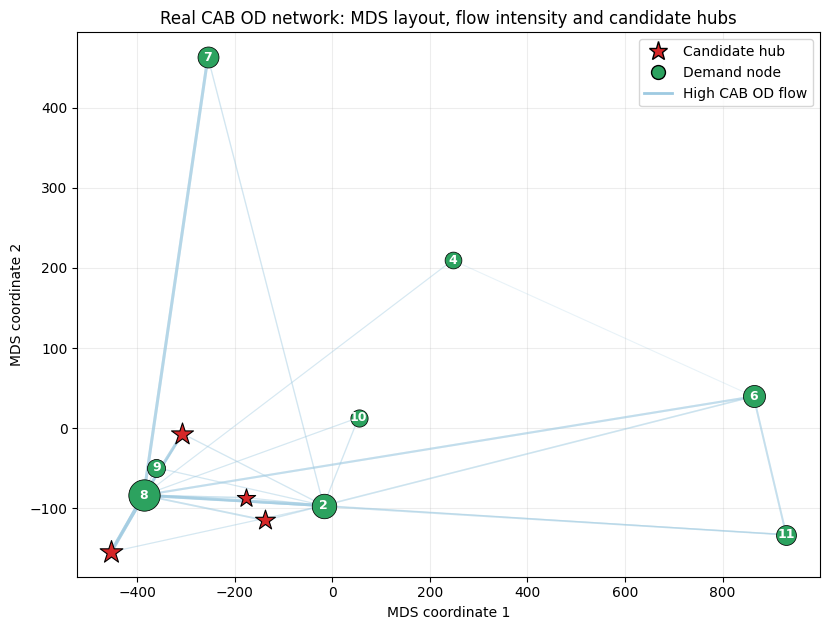

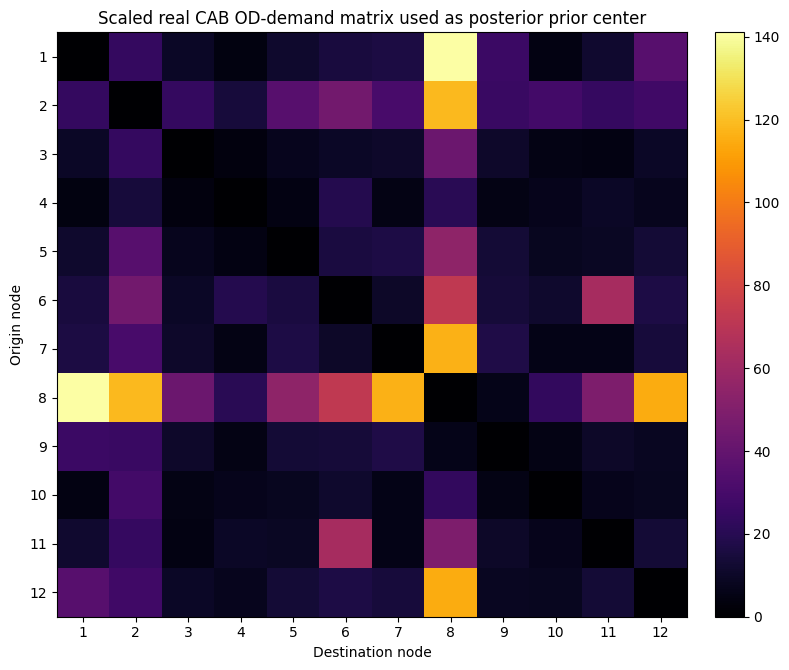

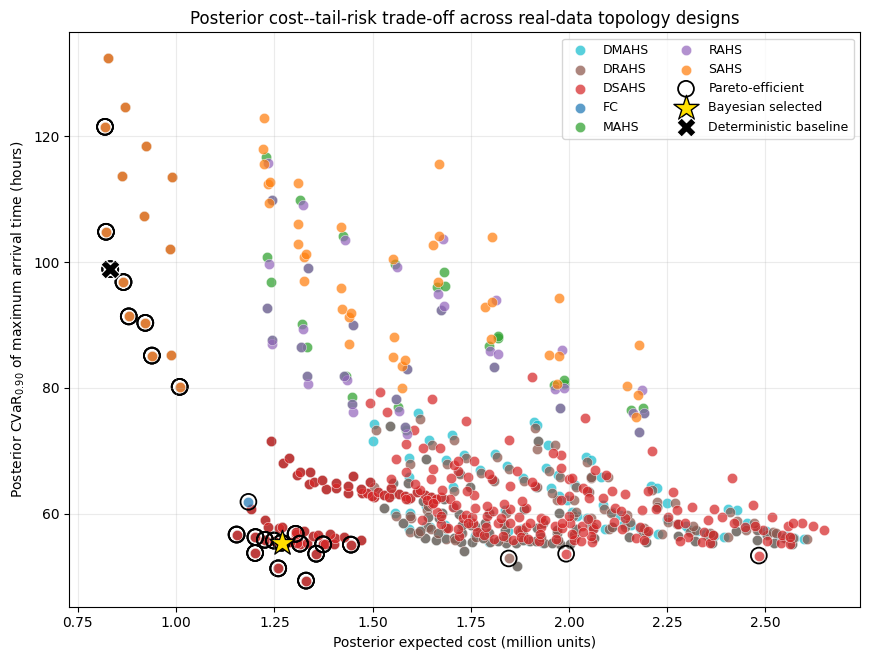

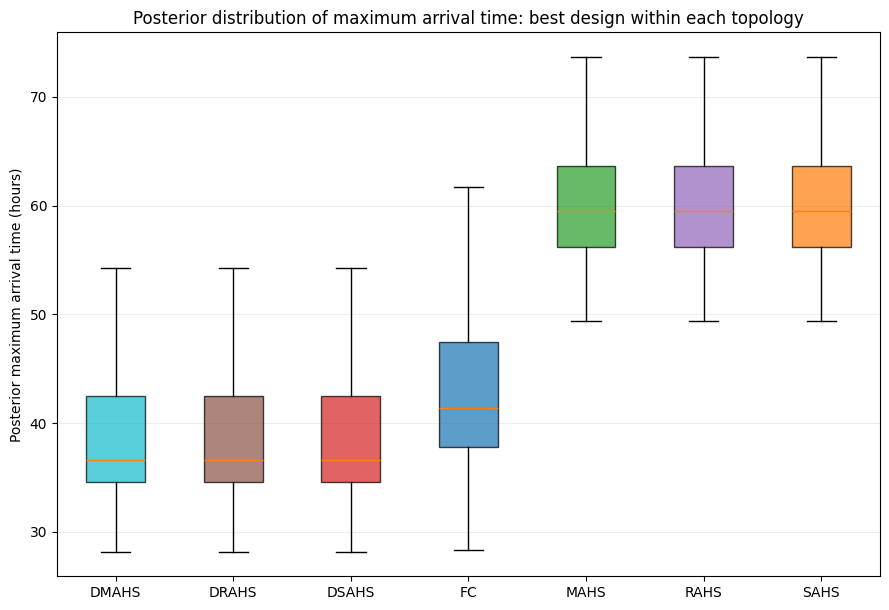

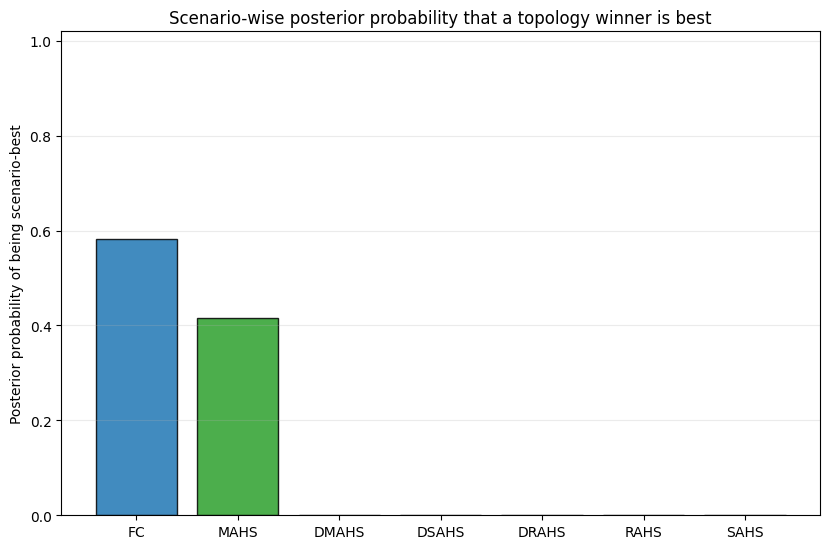

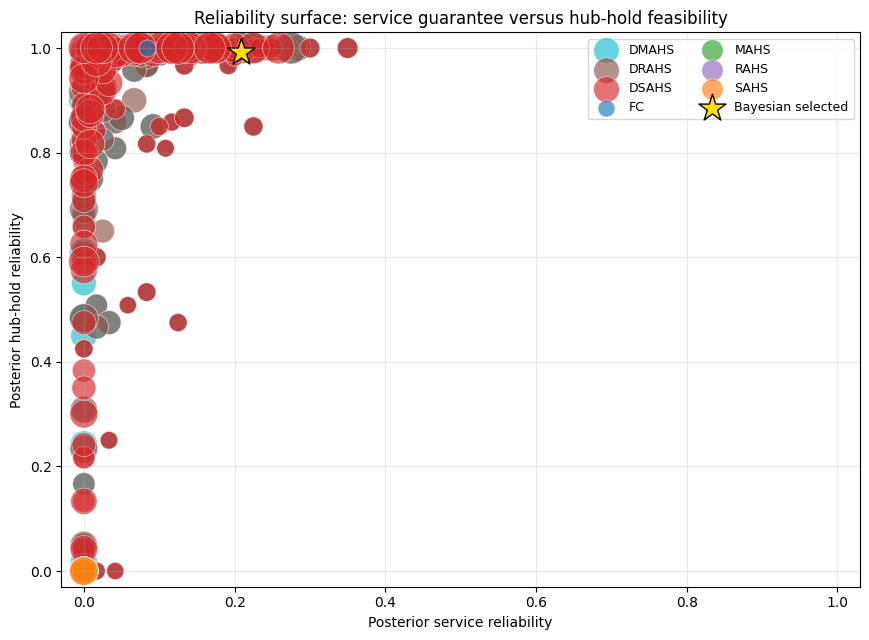

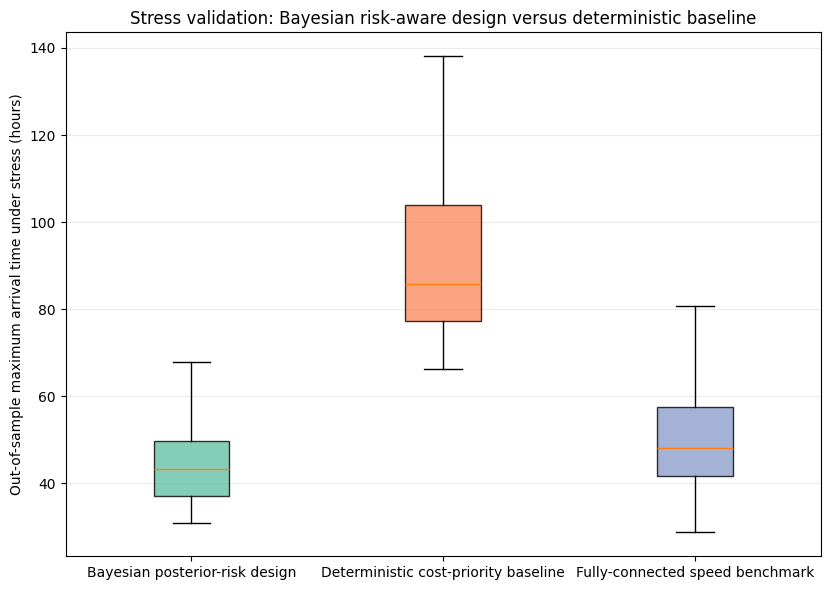

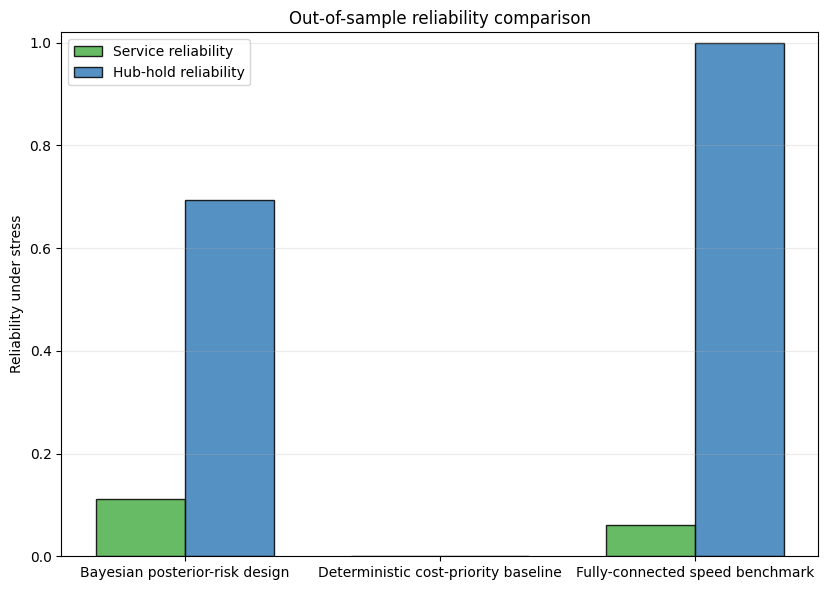

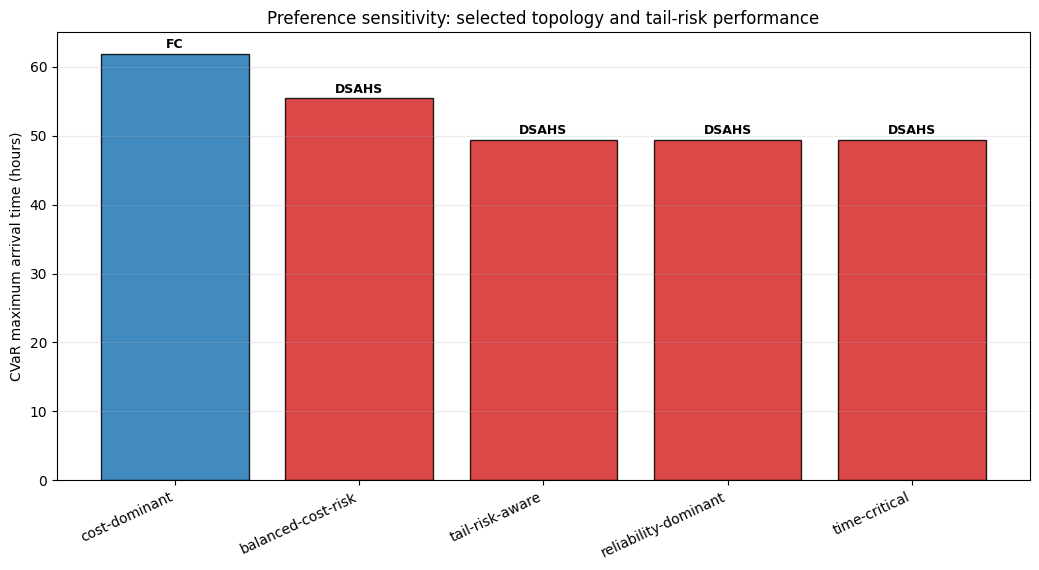

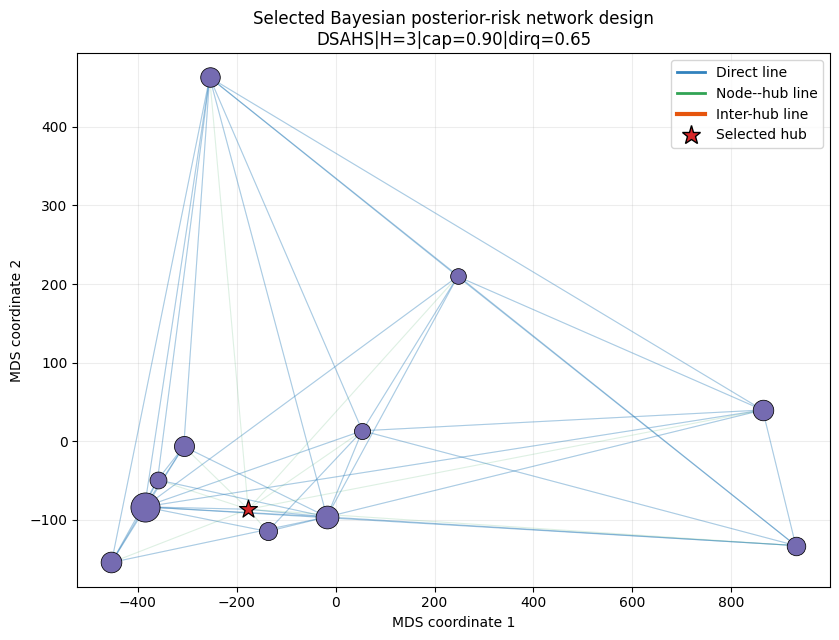

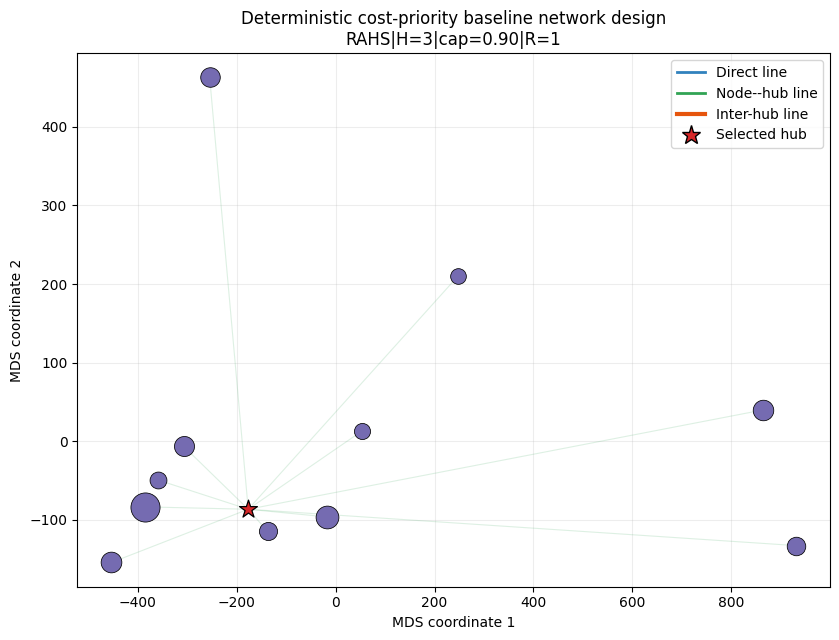

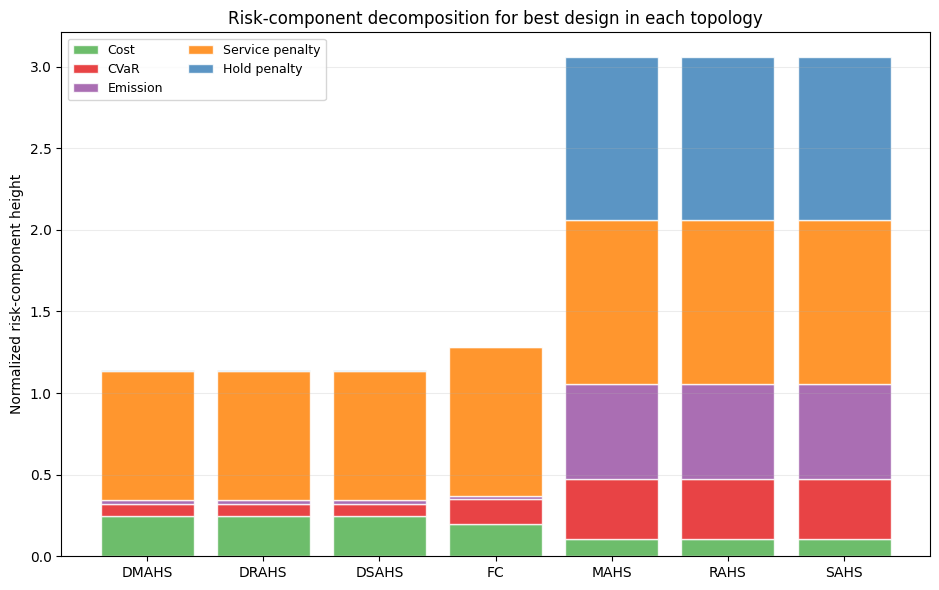


Selected Bayesian posterior-risk design:
DSAHS|H=3|cap=0.90|dirq=0.65

Deterministic baseline:
RAHS|H=3|cap=0.90|R=1

####################################################################################################
Case study finished successfully.
Outputs saved in: /content/cab_bayesian_etndp_outputs
Downloadable ZIP created: /content/cab_bayesian_etndp_outputs.zip
####################################################################################################


<Figure size 640x480 with 0 Axes>

In [2]:
%run case_study_cab_bayesian_etndp.py